# Modelo ML para predecir caudal horario - Sector 40 - version API

Este notebook mantiene el flujo del primer archivo: carga de Excel, limpieza, validacion de consignas, analisis exploratorio, entrenamiento, comparacion de modelos, graficas, importancia de variables y prediccion de escenarios.

La diferencia principal es que esta version guarda los archivos con nombres listos para usar en una API:

- `model.pkl`
- `scaler_X.pkl`
- `scaler_y.pkl`
- `model_metadata.pkl`

# Guia rapida para presentacion

El modelo busca estimar el **caudal promedio horario (lps)** a partir de la presion de salida, variables climaticas y patrones temporales. Antes de entrenar, se valida si la presion medida cumple la consigna horaria de la valvula.

El flujo es:

1. Cargar el Excel.
2. Limpiar datos y conservar filas completas.
3. Calcular consigna horaria de presion.
4. Filtrar condiciones operativas validas.
5. Crear variables temporales.
6. Entrenar varios modelos.
7. Elegir el mejor por menor MAE.
8. Guardar `model.pkl`, `scaler_X.pkl` y `scaler_y.pkl` para API.

Para la API, el orden de columnas es critico. Por eso tambien se guarda `model_metadata.pkl`, que contiene `feature_cols`.

## 1. Instalacion e importacion de librerias

Google Colab normalmente ya incluye la mayoria de librerias. `openpyxl` se instala para leer archivos Excel `.xlsx`.

In [6]:
!pip -q install openpyxl

import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42

In [1]:
!pip install scikit-learn==1.9.0

## 2. Cargar el archivo Excel en Colab

Ejecuta la celda y sube `Sector_40_CalculoUltimo.xlsx`.

In [7]:
uploaded = files.upload()
EXCEL_PATH = next(iter(uploaded.keys()))
print('Archivo cargado:', EXCEL_PATH)

Saving Sector_40_CalculoUltimo.xlsx to Sector_40_CalculoUltimo (2).xlsx
Archivo cargado: Sector_40_CalculoUltimo (2).xlsx


## 3. Parametros del archivo y de la consigna

Se usa la misma estructura del primer notebook: fecha/hora en B, caudal en D, presion salida en L, y clima en Y:AB.

In [10]:
HOJA = 'Hoja1'
FILA_INICIO = 18
FILA_FIN = 4169
N_FILAS = FILA_FIN - FILA_INICIO + 1

TOLERANCIA_MCA = 2.0
USAR_VARIABLES_TEMPORALES = True
FILTRAR_VALORES_RAROS = True

## 4. Lectura y limpieza inicial

Se leen solo las columnas necesarias, se convierten tipos de datos y se eliminan filas incompletas.

In [11]:
df = pd.read_excel(
    EXCEL_PATH,
    sheet_name=HOJA,
    header=None,
    usecols='B,D,L,Y:AB',
    skiprows=FILA_INICIO - 1,
    nrows=N_FILAS,
)

df.columns = [
    'fecha_hora',
    'caudal_lps',
    'presion_salida_mca',
    'temperatura_c',
    'precipitacion_mm_h',
    'humedad_pct',
    'viento_m_s',
]

df['fecha_hora'] = pd.to_datetime(df['fecha_hora'], errors='coerce')
numeric_cols = ['caudal_lps', 'presion_salida_mca', 'temperatura_c', 'precipitacion_mm_h', 'humedad_pct', 'viento_m_s']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['fecha_hora'] + numeric_cols).copy()
df = df.sort_values('fecha_hora').reset_index(drop=True)

print('Filas completas:', len(df))
print('Desde:', df['fecha_hora'].min())
print('Hasta:', df['fecha_hora'].max())
display(df.head())
display(df.tail())

Filas completas: 3974
Desde: 2026-01-01 01:00:00
Hasta: 2026-06-23 00:00:00


,fecha_hora,caudal_lps,presion_salida_mca,temperatura_c,precipitacion_mm_h,humedad_pct,viento_m_s
0,2026-01-01 01:00:00,86.522715,8.786689,19.7,0.0,89.0,0.4
1,2026-01-01 02:00:00,79.000000,8.378566,19.7,0.0,89.0,0.3
2,2026-01-01 03:00:00,75.072630,8.455518,19.9,0.0,85.0,0.1
3,2026-01-01 04:00:00,67.591629,8.067553,19.6,0.0,86.0,0.2
4,2026-01-01 05:00:00,67.080763,0.000000,19.4,0.0,86.0,0.0


,fecha_hora,caudal_lps,presion_salida_mca,temperatura_c,precipitacion_mm_h,humedad_pct,viento_m_s
3969,2026-06-22 19:00:00,142.513072,16.293062,20.9,0.0,76.0,1.8
3970,2026-06-22 20:00:00,128.058958,16.440457,20.7,0.0,76.0,1.3
3971,2026-06-22 22:00:00,124.780918,9.941525,20.7,0.0,78.0,0.6
3972,2026-06-22 23:00:00,118.878900,9.559805,20.8,0.0,77.0,0.8
3973,2026-06-23 00:00:00,96.287056,8.678798,20.9,0.0,77.0,0.4


## 5. Consigna horaria de presion

Se calcula la presion objetivo segun la hora de operacion de la valvula y se verifica si la presion medida cumple la consigna.

In [12]:
def consigna_presion(fecha_hora):
    hora_decimal = fecha_hora.hour + fecha_hora.minute / 60

    if 6 <= hora_decimal < 7:
        return 10.0
    if 7 <= hora_decimal < (19 + 10 / 60):
        return 16.0
    if (19 + 10 / 60) <= hora_decimal < 23:
        return 10.0
    return 8.0

df['consigna_mca'] = df['fecha_hora'].apply(consigna_presion)
df['error_consigna_mca'] = (df['presion_salida_mca'] - df['consigna_mca']).abs()
df['cumple_consigna'] = df['error_consigna_mca'] <= TOLERANCIA_MCA

resumen_consigna = (
    df.groupby('consigna_mca')
    .agg(
        filas=('caudal_lps', 'size'),
        presion_prom=('presion_salida_mca', 'mean'),
        error_prom=('error_consigna_mca', 'mean'),
        cumplimiento=('cumple_consigna', 'mean'),
    )
    .round(3)
)

display(resumen_consigna)
print('Filas que cumplen consigna:', df['cumple_consigna'].sum(), 'de', len(df))

,filas,presion_prom,error_prom,cumplimiento
consigna_mca,,,,
8.0,1141,8.285,1.157,0.840
10.0,662,9.264,1.777,0.627
16.0,2171,14.439,2.120,0.818


Filas que cumplen consigna: 3150 de 3974


## 6. Analisis exploratorio rapido

Esta seccion conserva las graficas del primer notebook: estadisticos, histogramas y matriz de correlacion.

,count,mean,std,min,25%,50%,75%,max
caudal_lps,3974.0,129.589,52.018,0.000,84.382,131.481,176.841,230.10
presion_salida_mca,3974.0,11.810,4.423,0.000,8.568,10.781,16.112,18.72
temperatura_c,3974.0,23.293,2.559,0.000,21.400,22.700,24.900,33.20
precipitacion_mm_h,3974.0,0.000,0.000,0.000,0.000,0.000,0.000,0.00
humedad_pct,3974.0,78.197,10.954,0.000,70.000,80.000,86.000,100.00
viento_m_s,3974.0,0.568,0.513,0.000,0.200,0.400,0.900,4.00
consigna_mca,3974.0,12.704,3.676,8.000,8.000,16.000,16.000,16.00
error_consigna_mca,3974.0,1.786,3.065,0.002,0.399,0.667,1.361,16.00


Variables sin variacion en el rango analizado: ['precipitacion_mm_h']
Advertencia: una variable sin variacion no aporta informacion predictiva en este archivo.


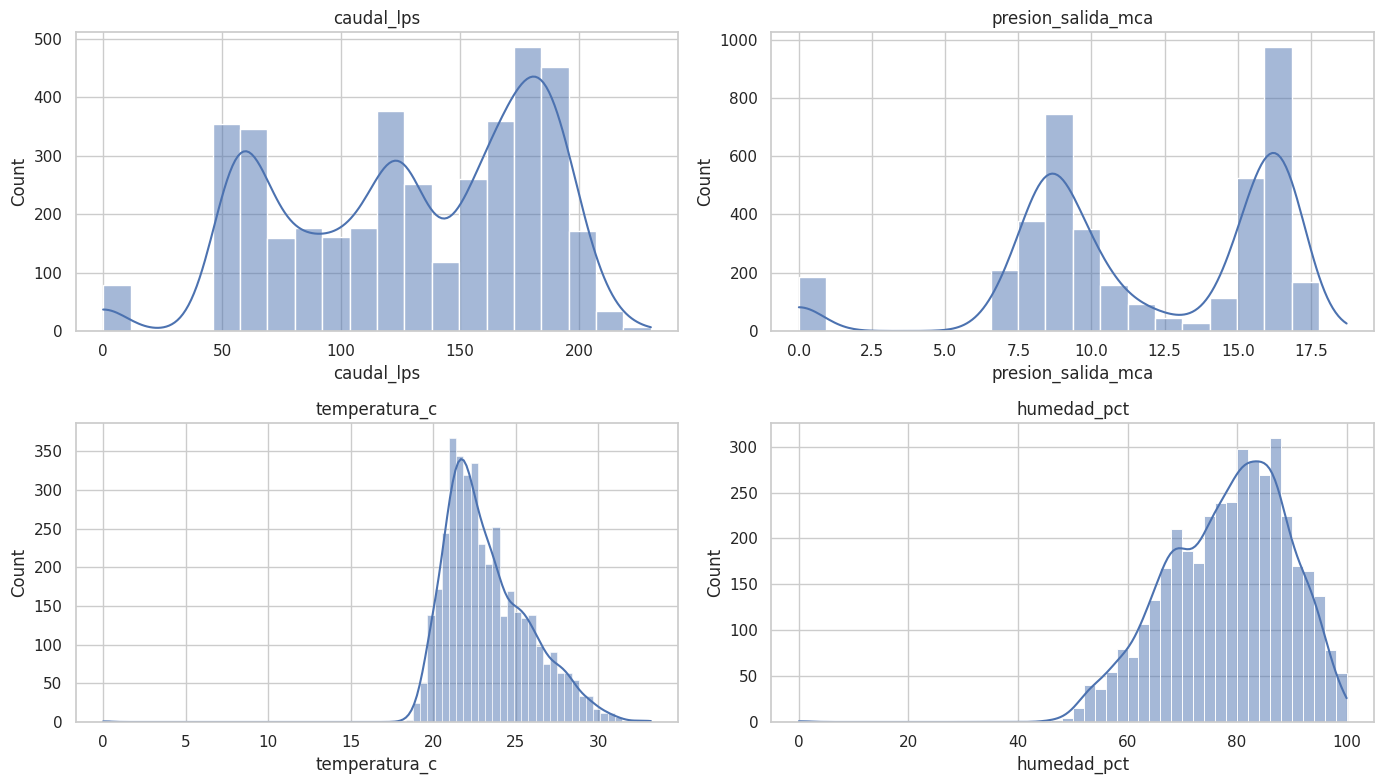

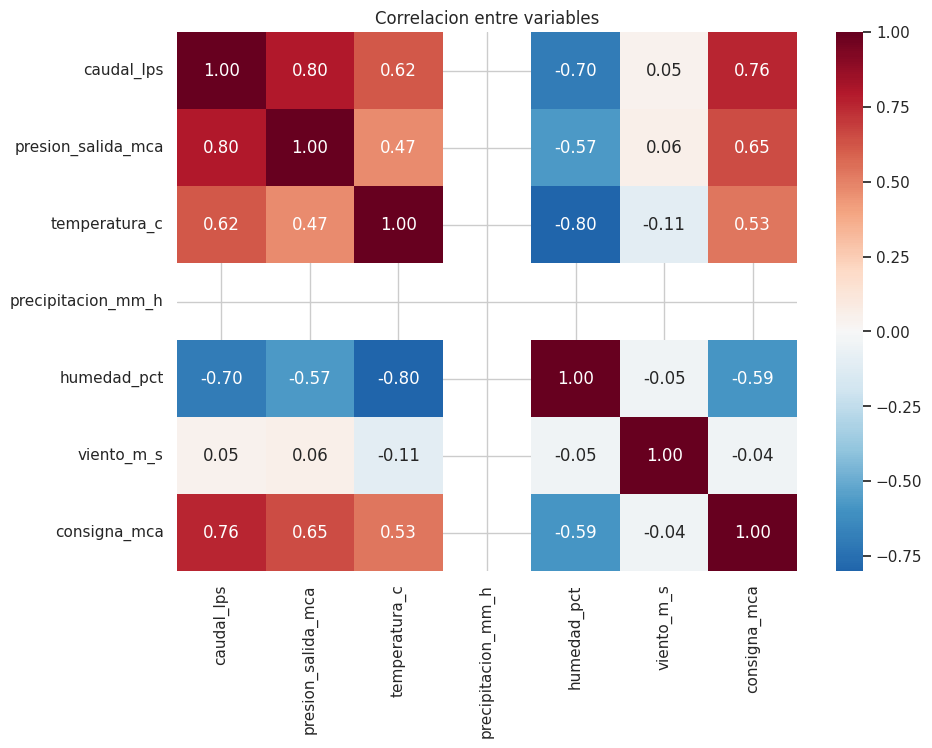

In [13]:
display(df[numeric_cols + ['consigna_mca', 'error_consigna_mca']].describe().T.round(3))

clima_cols = ['temperatura_c', 'precipitacion_mm_h', 'humedad_pct', 'viento_m_s']
sin_variacion = [col for col in clima_cols if df[col].nunique(dropna=True) <= 1]
if sin_variacion:
    print('Variables sin variacion en el rango analizado:', sin_variacion)
    print('Advertencia: una variable sin variacion no aporta informacion predictiva en este archivo.')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()
for ax, col in zip(axes, ['caudal_lps', 'presion_salida_mca', 'temperatura_c', 'humedad_pct']):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
corr_cols = ['caudal_lps', 'presion_salida_mca', 'temperatura_c', 'precipitacion_mm_h', 'humedad_pct', 'viento_m_s', 'consigna_mca']
sns.heatmap(df[corr_cols].corr(numeric_only=True), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlacion entre variables')
plt.show()

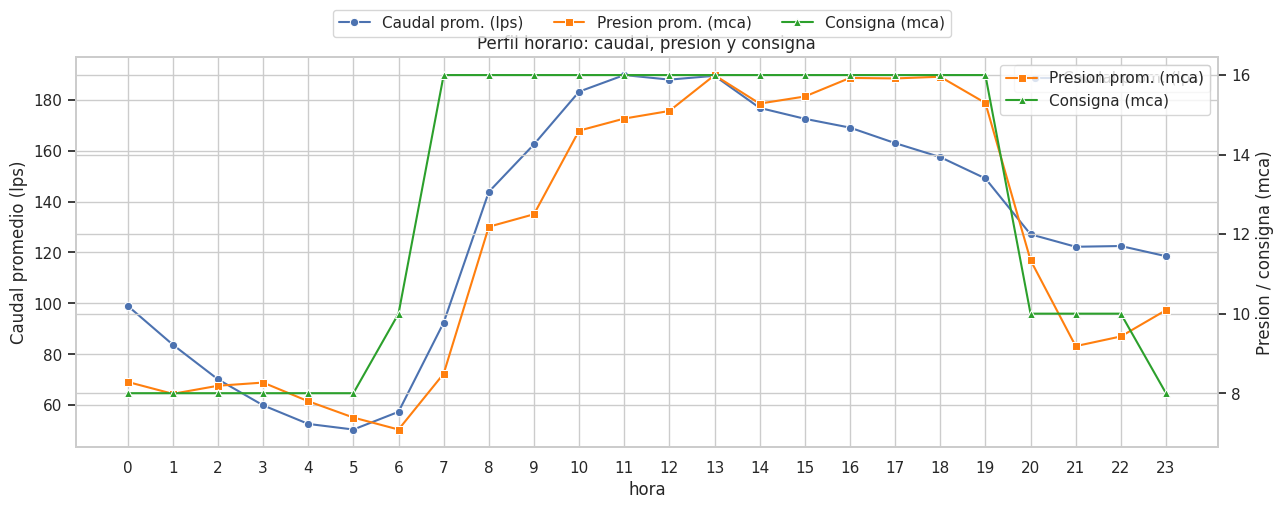

In [14]:
df['hora'] = df['fecha_hora'].dt.hour
df['dia_semana'] = df['fecha_hora'].dt.dayofweek
df['mes'] = df['fecha_hora'].dt.month

perfil_horario = (
    df.groupby('hora')
    .agg(
        caudal_prom=('caudal_lps', 'mean'),
        presion_prom=('presion_salida_mca', 'mean'),
        consigna_prom=('consigna_mca', 'mean'),
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(13, 5))
sns.lineplot(data=perfil_horario, x='hora', y='caudal_prom', marker='o', ax=ax1, label='Caudal prom. (lps)')
ax1.set_ylabel('Caudal promedio (lps)')
ax1.set_xticks(range(0, 24))

ax2 = ax1.twinx()
sns.lineplot(data=perfil_horario, x='hora', y='presion_prom', marker='s', ax=ax2, color='tab:orange', label='Presion prom. (mca)')
sns.lineplot(data=perfil_horario, x='hora', y='consigna_prom', marker='^', ax=ax2, color='tab:green', label='Consigna (mca)')
ax2.set_ylabel('Presion / consigna (mca)')

ax1.set_title('Perfil horario: caudal, presion y consigna')
fig.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.03))
plt.tight_layout()
plt.show()

## 7. Preparar datos para el modelo

Se filtran filas que cumplen consigna, se eliminan valores raros y se crean variables temporales ciclicas.

In [15]:
df_model = df[df['cumple_consigna']].copy()

if FILTRAR_VALORES_RAROS:
    df_model = df_model[
        (df_model['caudal_lps'] > 0) &
        (df_model['presion_salida_mca'] > 0) &
        (df_model['temperatura_c'].between(5, 45)) &
        (df_model['humedad_pct'].between(1, 100)) &
        (df_model['viento_m_s'] >= 0)
    ].copy()

df_model['hora_sin'] = np.sin(2 * np.pi * df_model['hora'] / 24)
df_model['hora_cos'] = np.cos(2 * np.pi * df_model['hora'] / 24)
df_model['dow_sin'] = np.sin(2 * np.pi * df_model['dia_semana'] / 7)
df_model['dow_cos'] = np.cos(2 * np.pi * df_model['dia_semana'] / 7)

feature_cols = ['presion_salida_mca', 'temperatura_c', 'precipitacion_mm_h', 'humedad_pct', 'viento_m_s']
if USAR_VARIABLES_TEMPORALES:
    feature_cols += ['hora_sin', 'hora_cos', 'dow_sin', 'dow_cos', 'mes']

target_col = 'caudal_lps'

print('Filas para modelar:', len(df_model))
print('Variables de entrada:', feature_cols)
display(df_model[['fecha_hora', target_col] + feature_cols].head())

Filas para modelar: 3145
Variables de entrada: ['presion_salida_mca', 'temperatura_c', 'precipitacion_mm_h', 'humedad_pct', 'viento_m_s', 'hora_sin', 'hora_cos', 'dow_sin', 'dow_cos', 'mes']


,fecha_hora,caudal_lps,presion_salida_mca,temperatura_c,precipitacion_mm_h,humedad_pct,viento_m_s,hora_sin,hora_cos,dow_sin,dow_cos,mes
0,2026-01-01 01:00:00,86.522715,8.786689,19.7,0.0,89.0,0.4,0.258819,9.659258e-01,0.433884,-0.900969,1
1,2026-01-01 02:00:00,79.000000,8.378566,19.7,0.0,89.0,0.3,0.500000,8.660254e-01,0.433884,-0.900969,1
2,2026-01-01 03:00:00,75.072630,8.455518,19.9,0.0,85.0,0.1,0.707107,7.071068e-01,0.433884,-0.900969,1
3,2026-01-01 04:00:00,67.591629,8.067553,19.6,0.0,86.0,0.2,0.866025,5.000000e-01,0.433884,-0.900969,1
5,2026-01-01 06:00:00,59.925774,8.438446,19.1,0.0,89.0,0.1,1.000000,6.123234e-17,0.433884,-0.900969,1


## 8. Separacion entrenamiento/prueba

Se usa una separacion temporal: el primer 80% para entrenar y el ultimo 20% para evaluar.

In [16]:
df_model = df_model.sort_values('fecha_hora').reset_index(drop=True)

split_idx = int(len(df_model) * 0.80)
train = df_model.iloc[:split_idx].copy()
test = df_model.iloc[split_idx:].copy()

X_train = train[feature_cols]
y_train = train[target_col]
X_test = test[feature_cols]
y_test = test[target_col]

print('Train:', train['fecha_hora'].min(), '->', train['fecha_hora'].max(), '| filas:', len(train))
print('Test :', test['fecha_hora'].min(), '->', test['fecha_hora'].max(), '| filas:', len(test))

Train: 2026-01-01 01:00:00 -> 2026-05-17 22:00:00 | filas: 2516
Test : 2026-05-18 00:00:00 -> 2026-06-23 00:00:00 | filas: 629


## 9. Entrenar y comparar modelos

Se comparan una linea base, un modelo lineal y dos modelos no lineales. El mejor se elige por menor MAE.

In [17]:
models = {
    'Promedio historico': DummyRegressor(strategy='mean'),
    'Ridge': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0)),
    ]),
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestRegressor(n_estimators=500, max_depth=14, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    'Gradient Boosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', HistGradientBoostingRegressor(max_iter=500, learning_rate=0.04, l2_regularization=0.01, random_state=RANDOM_STATE)),
    ]),
}

resultados = []
predicciones = {}

for nombre, model_tmp in models.items():
    model_tmp.fit(X_train, y_train)
    y_pred = model_tmp.predict(X_test)
    predicciones[nombre] = y_pred
    resultados.append({
        'modelo': nombre,
        'MAE_lps': mean_absolute_error(y_test, y_pred),
        'RMSE_lps': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),
    })

resultados_df = pd.DataFrame(resultados).sort_values('MAE_lps').reset_index(drop=True)
display(resultados_df.round(3))

mejor_modelo_nombre = resultados_df.loc[0, 'modelo']
mejor_modelo = models[mejor_modelo_nombre]
test = test.copy()
test['caudal_pred_lps'] = predicciones[mejor_modelo_nombre]
test['residuo_lps'] = test['caudal_lps'] - test['caudal_pred_lps']

print('Mejor modelo por MAE:', mejor_modelo_nombre)

,modelo,MAE_lps,RMSE_lps,R2
0,Random Forest,4.914,7.641,0.974
1,Gradient Boosting,4.936,7.532,0.975
2,Ridge,15.516,18.062,0.855
3,Promedio historico,41.158,47.445,-0.002


Mejor modelo por MAE: Random Forest


## 10. Visualizar predicciones

Se conservan las graficas principales del primer notebook: real vs predicho, dispersion, residuos y residuos por hora.

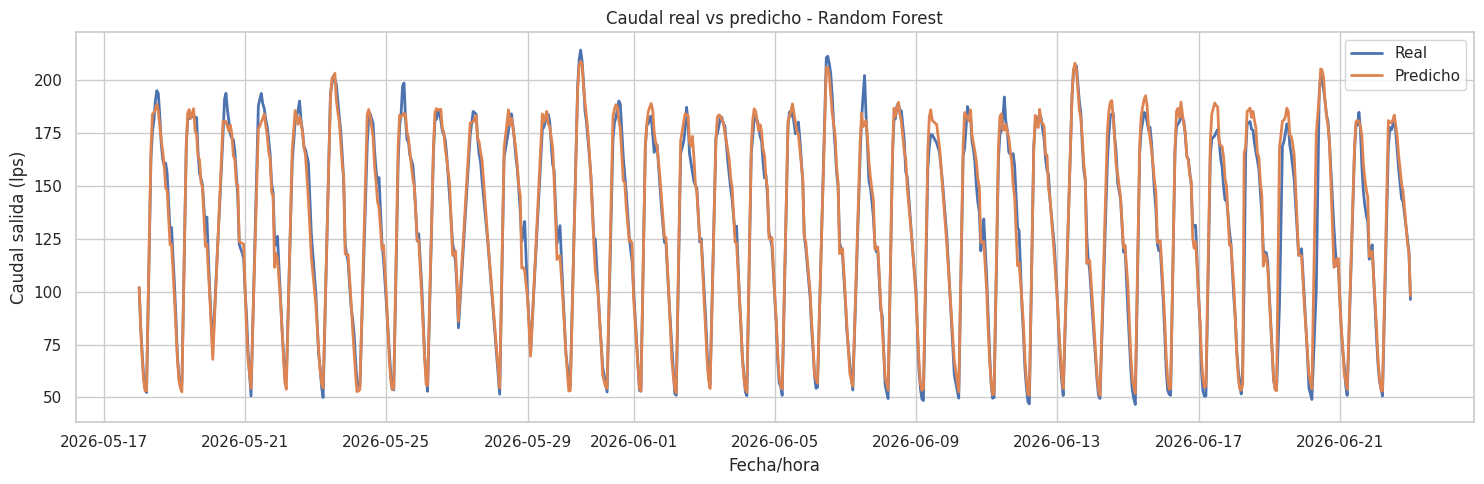

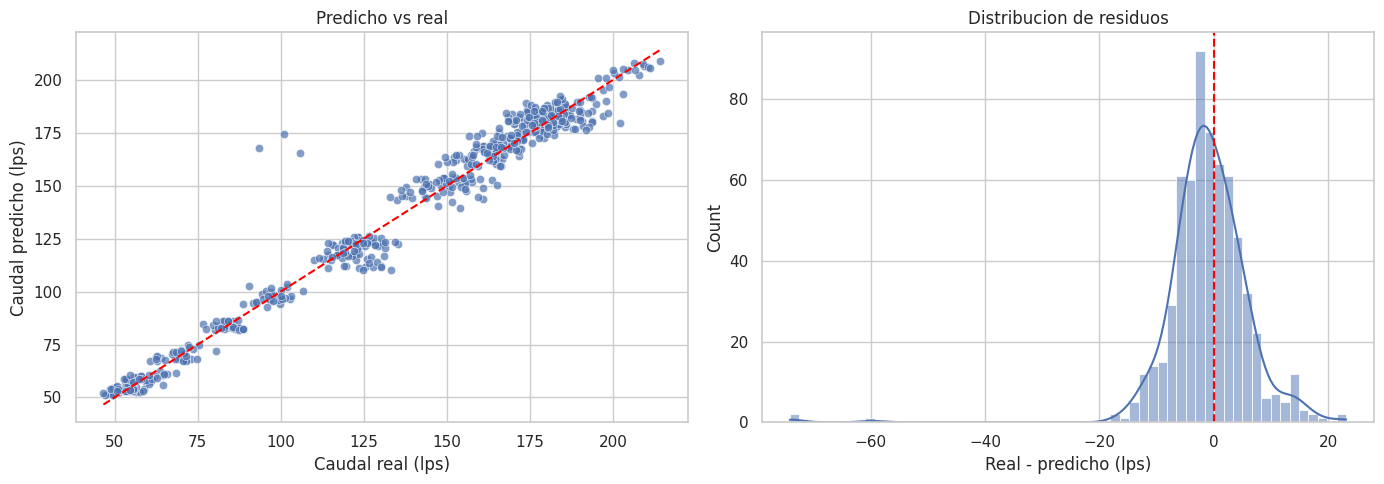

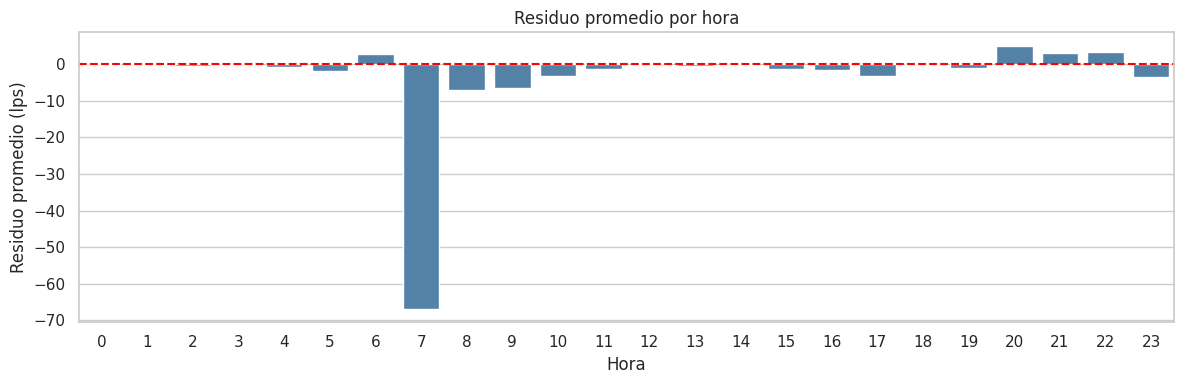

In [18]:
plt.figure(figsize=(15, 5))
plt.plot(test['fecha_hora'], test['caudal_lps'], label='Real', linewidth=2)
plt.plot(test['fecha_hora'], test['caudal_pred_lps'], label='Predicho', linewidth=2)
plt.title(f'Caudal real vs predicho - {mejor_modelo_nombre}')
plt.xlabel('Fecha/hora')
plt.ylabel('Caudal salida (lps)')
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=test['caudal_lps'], y=test['caudal_pred_lps'], ax=axes[0], alpha=0.7)
min_val = min(test['caudal_lps'].min(), test['caudal_pred_lps'].min())
max_val = max(test['caudal_lps'].max(), test['caudal_pred_lps'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
axes[0].set_title('Predicho vs real')
axes[0].set_xlabel('Caudal real (lps)')
axes[0].set_ylabel('Caudal predicho (lps)')

sns.histplot(test['residuo_lps'], kde=True, ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribucion de residuos')
axes[1].set_xlabel('Real - predicho (lps)')

plt.tight_layout()
plt.show()

residuo_hora = test.groupby('hora')['residuo_lps'].agg(['mean', 'std', 'count']).reset_index()
plt.figure(figsize=(12, 4))
sns.barplot(data=residuo_hora, x='hora', y='mean', color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuo promedio por hora')
plt.xlabel('Hora')
plt.ylabel('Residuo promedio (lps)')
plt.tight_layout()
plt.show()

## 11. Importancia de variables

La importancia por permutacion permite explicar que variables influyen mas en las predicciones.

,variable,importancia_mae_lps,desv_est
0,presion_salida_mca,28.7894,1.2815
5,hora_sin,11.4677,0.7134
6,hora_cos,7.8467,0.3196
7,dow_sin,1.3362,0.1458
1,temperatura_c,0.6320,0.0553
3,humedad_pct,0.0138,0.0580
4,viento_m_s,0.0124,0.0195
9,mes,-0.0000,0.0000
2,precipitacion_mm_h,-0.0000,0.0000
8,dow_cos,-0.0464,0.0334


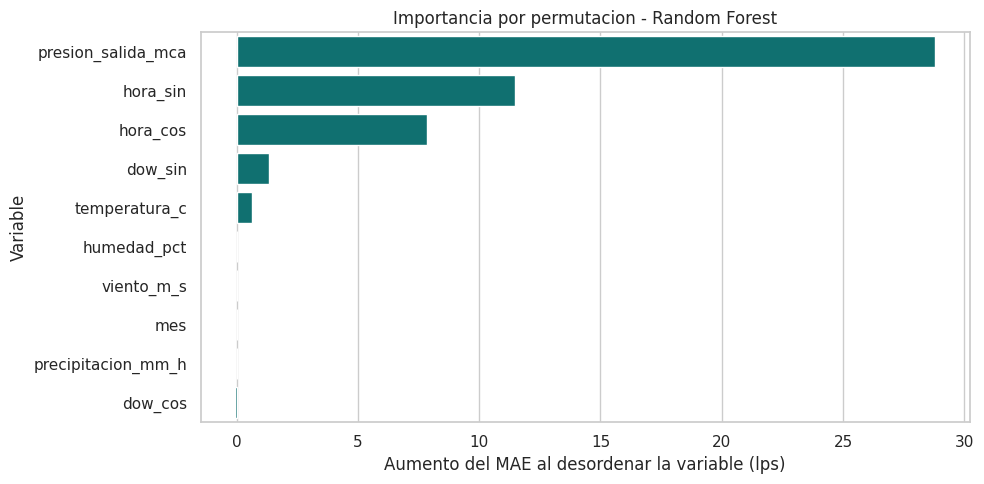

In [19]:
perm = permutation_importance(
    mejor_modelo,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)

importancia_df = pd.DataFrame({
    'variable': feature_cols,
    'importancia_mae_lps': perm.importances_mean,
    'desv_est': perm.importances_std,
}).sort_values('importancia_mae_lps', ascending=False)

display(importancia_df.round(4))

plt.figure(figsize=(10, 5))
sns.barplot(data=importancia_df, x='importancia_mae_lps', y='variable', color='teal')
plt.title(f'Importancia por permutacion - {mejor_modelo_nombre}')
plt.xlabel('Aumento del MAE al desordenar la variable (lps)')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

## 12. Funcion para predecir nuevos escenarios

Esta funcion prepara nuevas observaciones con las mismas variables usadas en entrenamiento.

In [20]:
def preparar_escenarios(nuevos):
    nuevos = nuevos.copy()
    nuevos['fecha_hora'] = pd.to_datetime(nuevos['fecha_hora'])
    nuevos['hora'] = nuevos['fecha_hora'].dt.hour
    nuevos['dia_semana'] = nuevos['fecha_hora'].dt.dayofweek
    nuevos['mes'] = nuevos['fecha_hora'].dt.month
    nuevos['hora_sin'] = np.sin(2 * np.pi * nuevos['hora'] / 24)
    nuevos['hora_cos'] = np.cos(2 * np.pi * nuevos['hora'] / 24)
    nuevos['dow_sin'] = np.sin(2 * np.pi * nuevos['dia_semana'] / 7)
    nuevos['dow_cos'] = np.cos(2 * np.pi * nuevos['dia_semana'] / 7)
    nuevos['consigna_mca'] = nuevos['fecha_hora'].apply(consigna_presion)
    nuevos['error_consigna_mca'] = (nuevos['presion_salida_mca'] - nuevos['consigna_mca']).abs()
    nuevos['cumple_consigna'] = nuevos['error_consigna_mca'] <= TOLERANCIA_MCA
    return nuevos

escenarios = pd.DataFrame([
    {
        'fecha_hora': '2026-06-18 08:00:00',
        'presion_salida_mca': 16.0,
        'temperatura_c': 22.5,
        'precipitacion_mm_h': 0.0,
        'humedad_pct': 80.0,
        'viento_m_s': 0.5,
    },
    {
        'fecha_hora': '2026-06-18 23:00:00',
        'presion_salida_mca': 8.0,
        'temperatura_c': 21.5,
        'precipitacion_mm_h': 0.0,
        'humedad_pct': 85.0,
        'viento_m_s': 0.3,
    },
])

escenarios_prep = preparar_escenarios(escenarios)
escenarios_prep['caudal_pred_lps'] = mejor_modelo.predict(escenarios_prep[feature_cols])

display(escenarios_prep[['fecha_hora', 'consigna_mca', 'presion_salida_mca', 'cumple_consigna', 'caudal_pred_lps']].round(3))

,fecha_hora,consigna_mca,presion_salida_mca,cumple_consigna,caudal_pred_lps
0,2026-06-18 08:00:00,16.0,16.0,True,169.150
1,2026-06-18 23:00:00,8.0,8.0,True,117.537


## 13. Guardar archivos para API

Esta version guarda el mejor modelo como `model.pkl`, y tambien guarda `scaler_X.pkl` y `scaler_y.pkl`.

`model_metadata.pkl` conserva las columnas esperadas por la API.

In [21]:
def obtener_estimador_base(modelo_entrenado):
    """Extrae el estimador final si el mejor modelo esta dentro de un Pipeline."""
    if hasattr(modelo_entrenado, 'named_steps') and 'model' in modelo_entrenado.named_steps:
        return clone(modelo_entrenado.named_steps['model'])
    return clone(modelo_entrenado)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.to_numpy().reshape(-1, 1)).ravel()

model_api = obtener_estimador_base(mejor_modelo)
model_api.fit(X_train_scaled, y_train_scaled)

X_test_scaled = scaler_X.transform(X_test)
y_pred_scaled = model_api.predict(X_test_scaled)
y_pred_lps = scaler_y.inverse_transform(np.asarray(y_pred_scaled).reshape(-1, 1)).ravel()

print('Modelo exportado para API:', mejor_modelo_nombre)
print('MAE API (lps):', round(mean_absolute_error(y_test, y_pred_lps), 3))
print('RMSE API (lps):', round(np.sqrt(mean_squared_error(y_test, y_pred_lps)), 3))
print('R2 API:', round(r2_score(y_test, y_pred_lps), 3))

metadata = {
    'modelo_nombre': mejor_modelo_nombre,
    'feature_cols': feature_cols,
    'target_col': target_col,
    'tolerancia_mca': TOLERANCIA_MCA,
    'usar_variables_temporales': USAR_VARIABLES_TEMPORALES,
}

joblib.dump(model_api, 'model.pkl')
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')
joblib.dump(metadata, 'model_metadata.pkl')

print('Archivos guardados correctamente:')
print('- model.pkl')
print('- scaler_X.pkl')
print('- scaler_y.pkl')
print('- model_metadata.pkl')

Modelo exportado para API: Random Forest
MAE API (lps): 4.922
RMSE API (lps): 7.664
R2 API: 0.974
Archivos guardados correctamente:
- model.pkl
- scaler_X.pkl
- scaler_y.pkl
- model_metadata.pkl


## 14. Cargar el mejor modelo y sus scalers

Esta celda contiene exactamente el formato solicitado para usar los archivos en una API.

In [22]:
import joblib

# Load the best model
model = joblib.load('model.pkl')

# Load the scalers
scaler_X = joblib.load('scaler_X.pkl')
scaler_y = joblib.load('scaler_y.pkl')

print("Model and scalers loaded successfully!")

Model and scalers loaded successfully!


## 15. Ejemplo de prediccion usando archivos API

El flujo correcto para una API es: preparar variables, ordenar columnas, aplicar `scaler_X`, predecir con `model` y devolver el resultado a lps con `scaler_y.inverse_transform`.

In [26]:
def predecir_caudal_api(nuevos):
    nuevos_preparados = preparar_escenarios(nuevos)
    # Using the globally defined feature_cols directly
    X = nuevos_preparados[feature_cols]
    X_scaled = scaler_X.transform(X)
    y_scaled = model.predict(X_scaled)
    y_lps = scaler_y.inverse_transform(np.asarray(y_scaled).reshape(-1, 1)).ravel()
    nuevos_preparados['caudal_pred_lps_api'] = y_lps
    return nuevos_preparados

nuevos_escenarios = pd.DataFrame([
    {
        'fecha_hora': '2026-06-18 10:00:00',
        'presion_salida_mca': 16.0,
        'temperatura_c': 24.0,
        'precipitacion_mm_h': 0.0,
        'humedad_pct': 70.0,
        'viento_m_s': 1.0,
    },
    {
        'fecha_hora': '2026-06-18 02:00:00',
        'presion_salida_mca': 8.0,
        'temperatura_c': 18.0,
        'precipitacion_mm_h': 0.0,
        'humedad_pct': 90.0,
        'viento_m_s': 0.2,
    },
])

predicciones_api = predecir_caudal_api(nuevos_escenarios)
display(predicciones_api[['fecha_hora', 'consigna_mca', 'presion_salida_mca', 'cumple_consigna', 'caudal_pred_lps_api']].round(3))

,fecha_hora,consigna_mca,presion_salida_mca,cumple_consigna,caudal_pred_lps_api
0,2026-06-18 10:00:00,16.0,16.0,True,183.113
1,2026-06-18 02:00:00,8.0,8.0,True,65.173


## 16. Descargar archivos para API

Descarga los archivos generados para usarlos en tu API.

In [24]:
files.download('model.pkl')
files.download('scaler_X.pkl')
files.download('scaler_y.pkl')
files.download('model_metadata.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>